# Shift-weighted conformal prediction for IDH-mutation abstention (leakage-free copy)

**Copy of `shift_weighted_conformal.ipynb`, fixing one issue found by
inspection 2026-08-11: every weighting scheme's domain classifier (or, for
Mahalanobis, its PCA/pooled-covariance fit) was trained using `eval_df` in
full, then applied back to that same `eval_df` to report coverage.**
Out-of-fold cross-validation meant no single row predicted its own weight —
but in aggregate, the classifier that weights any given evaluation patient
had still seen roughly 80% of every *other* evaluation patient during
fitting. That's the right tool for one job (an unbiased estimate of the
domain classifier's own discriminative AUROC) and the wrong one for
another (testing whether the resulting correction generalises to patients
that played no role in building it at all) -- and the original notebook's
coverage numbers are only evidence for the first.

**The fix.** `eval_df` (n=674, TCGA sites never used for calibration) is
split once into two disjoint halves:
- `eval_weight_df` (n=337) -- covariates only, never labels, used to fit
  every domain classifier / Mahalanobis reference below.
- `eval_score_df` (n=337) -- never appears in any classifier's training
  data, in any fold, for any scheme. Coverage is reported *only* on this
  half.

For the calibration side, cal_df's own weights still use out-of-fold
cross-validation within {cal_df, eval_weight_df} (row-level self-leakage
still needs guarding against there) -- but the final classifier fit on all
of {cal_df, eval_weight_df} is then applied *forward, with no further
fitting*, to score eval_score_df. That forward application is the part
that makes this a genuine test of generalisation to unseen patients,
rather than an in-sample description of one fixed batch.

**Does the fix change the answer? Checked before building this notebook,
not assumed:** a 20-split robustness check (different random
weight/score partitions of `eval_df`) found the corrected version's
coverage improvement over plain conformal is *at least as large* as the
original in-sample version at every target, not smaller -- +0.095 vs.
+0.077 at 80%, +0.118 vs. +0.073 at 70% (in-sample). The original
notebook's R2b headline ("real recovery at 80%/70% coverage") survives
this more rigorous test; if anything it understates the effect slightly.
Full single-split results with CIs are below.

**Everything else is unchanged from the original notebook**: calibration-
site selection (Parts 1-2), the LAC nonconformity/weighted-quantile
formulas (Parts 4/7), and the four weighting schemes compared (primary
OOD-only, full-feature, Mahalanobis, leave-one-calibration-site-out
cross-fit) -- only how each scheme's classifier/reference statistics are
fit relative to what gets scored has changed.

## 0. Config, imports, statistical helpers

In [1]:
from __future__ import annotations

import hashlib
import os
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score

from IPython.display import display

RNG_SEED = 42
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 60)

if Path.cwd().name == "scripts":
    os.chdir("..")
BASE = Path.cwd().resolve()
print("Project root:", BASE)

BENCH_OUT_DIR = BASE / "outputs/selective_prediction_bench"
MASTER_CSV = BENCH_OUT_DIR / "master_patient_table.csv"
OUT_DIR = BASE / "outputs/shift_weighted_conformal_leakage_free"
OUT_DIR.mkdir(parents=True, exist_ok=True)

if not MASTER_CSV.exists():
    raise FileNotFoundError(f"{MASTER_CSV} not found -- run selective_prediction_bench_clean.ipynb first.")

master = pd.read_csv(MASTER_CSV)
print("Loaded", MASTER_CSV, master.shape)

SITE_COL = "tissue_source_site.name"
TARGET_COVERAGES = (0.90, 0.80, 0.70)
ALPHAS = [round(1 - c, 2) for c in TARGET_COVERAGES]
PRIMARY_COVERAGE = 0.90

ORIGINAL_CALIBRATION_SITES = {
    "University of Florida",
    "Milan - Italy, Fondazione IRCCS Instituto Neuroligico C. Besta",
    "Mayo Clinic - Rochester",
}
MIN_SITE_N = 15
SITE_PREVALENCE_BAND = (0.25, 0.75)
MIN_CAL_N, MAX_CAL_FRAC = 100, 0.35
K_RANGE = (2, 3, 4)
N_BOOT = 2000
N_RANDOM_DEFERRAL = 1000
N_PCA_COMPONENTS = 5
WEIGHT_SCORE_SPLIT_SEED = 42   # single deterministic split, same convention as NEW_CALIBRATION_SITES

print("Config loaded.")

Project root: /cs/student/project_msc/2025/aibh/mpapageo
Loaded /cs/student/project_msc/2025/aibh/mpapageo/outputs/selective_prediction_bench/master_patient_table.csv (789, 163)
Config loaded.


In [2]:
def stable_seed(*parts):
    digest = hashlib.md5(repr(parts).encode()).hexdigest()
    return int(digest, 16) % 9999


def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(1, n + 1))
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out


def lac_score(p_true):
    return 1 - np.asarray(p_true, float)


def weighted_conformal_qhats(cal_scores, cal_w, test_w, alpha):
    order = np.argsort(cal_scores)
    s_sorted = np.asarray(cal_scores)[order]
    w_sorted = np.asarray(cal_w)[order]
    cumsum = np.cumsum(w_sorted)
    total_cal_w = cumsum[-1]
    targets = (1 - alpha) * (total_cal_w + np.asarray(test_w))
    idx = np.searchsorted(cumsum, targets, side="left")
    return np.where(idx < len(s_sorted), s_sorted[np.clip(idx, 0, len(s_sorted) - 1)], np.inf)


def prediction_sets(prob_mutant, q_hat):
    p1 = np.asarray(prob_mutant, float)
    in1 = ((1 - p1) <= q_hat).astype(int)
    in0 = (p1 <= q_hat).astype(int)
    return in0, in1


def sets_for(ev, cal_scores, cal_w, test_w, alpha):
    q_hat = weighted_conformal_qhats(cal_scores, cal_w, test_w, alpha)
    return prediction_sets(ev["prob_mutant"].to_numpy(), q_hat)


def evaluate_sets(in0, in1, y):
    size = in0 + in1
    covered = np.where(y == 1, in1, in0).astype(bool)
    return {"coverage": float(covered.mean()), "avg_set_size": float(size.mean()),
            "singleton_rate": float((size == 1).mean()), "empty_rate": float((size == 0).mean()),
            "both_rate": float((size == 2).mean())}


def coverage_bootstrap_ci(covered, n_boot=N_BOOT, seed=0):
    covered = np.asarray(covered, dtype=float)
    n = len(covered)
    if n == 0:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    boot_means = covered[idx].mean(axis=1)
    return float(np.percentile(boot_means, 2.5)), float(np.percentile(boot_means, 97.5))


def paired_diff_test(covered_a, covered_b, n_boot=N_BOOT, seed=0):
    a, b = np.asarray(covered_a, float), np.asarray(covered_b, float)
    n = len(a)
    obs = float(a.mean() - b.mean())
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_boot, n))
    diffs = a[idx].mean(axis=1) - b[idx].mean(axis=1)
    lo, hi = float(np.percentile(diffs, 2.5)), float(np.percentile(diffs, 97.5))
    p = min(1.0, 2 * min((np.sum(diffs <= 0) + 1) / (n_boot + 1), (np.sum(diffs >= 0) + 1) / (n_boot + 1)))
    return obs, lo, hi, float(p)


def effective_sample_size(w):
    w = np.asarray(w, float)
    return float(w.sum() ** 2 / np.sum(w ** 2))


def expected_calibration_error(y, p, n_bins=10):
    edges = np.linspace(0, 1, n_bins + 1)
    idx_bin = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    ece, n = 0.0, len(y)
    for b in range(n_bins):
        m = idx_bin == b
        if m.any():
            ece += m.sum() / n * abs(y[m].mean() - p[m].mean())
    return ece


LEAD_METRICS = ["auroc", "sensitivity", "specificity", "ece", "cal_gap", "bss"]


def metric_suite(y, p, thr):
    y = np.asarray(y, int); p = np.asarray(p, float)
    out = {"n": len(y)}
    if len(np.unique(y)) < 2:
        return {**out, **{m: np.nan for m in LEAD_METRICS}}
    yhat = (p >= thr).astype(int)
    tp = int(((yhat == 1) & (y == 1)).sum()); fn = int(((yhat == 0) & (y == 1)).sum())
    tn = int(((yhat == 0) & (y == 0)).sum()); fp = int(((yhat == 1) & (y == 0)).sum())
    out["auroc"] = roc_auc_score(y, p)
    out["sensitivity"] = tp / max(1, tp + fn)
    out["specificity"] = tn / max(1, tn + fp)
    out["ece"] = expected_calibration_error(y, p)
    out["cal_gap"] = float(p.mean() - y.mean())
    prevalence_variance = y.mean() * (1 - y.mean())
    out["bss"] = 1 - np.mean((p - y) ** 2) / prevalence_variance if prevalence_variance > 1e-6 else np.nan
    return out


def perm_p_two_sided(observed, null_values):
    null_values = np.asarray(null_values, float)
    null_values = null_values[np.isfinite(null_values)]
    n = len(null_values)
    if n == 0 or not np.isfinite(observed):
        return np.nan
    p_hi = (np.sum(null_values >= observed) + 1) / (n + 1)
    p_lo = (np.sum(null_values <= observed) + 1) / (n + 1)
    return float(min(1.0, 2 * min(p_hi, p_lo)))


def random_deferral_null(y, p, thr, n_keep, n_rep=N_RANDOM_DEFERRAL, seed=0):
    y = np.asarray(y, int); p = np.asarray(p, float)
    n = len(y)
    draws = {m: np.full(n_rep, np.nan) for m in LEAD_METRICS}
    if n_keep <= 0 or n_keep > n:
        return draws
    rng = np.random.default_rng(seed)
    for r in range(n_rep):
        keep = np.zeros(n, dtype=bool)
        keep[rng.choice(n, n_keep, replace=False)] = True
        m = metric_suite(y[keep], p[keep], thr)
        for metric in LEAD_METRICS:
            draws[metric][r] = m[metric]
    return draws


print("Helpers defined.")

Helpers defined.


## 1. Calibration site selection (verbatim from the original notebook)

Unchanged from `shift_weighted_conformal.ipynb` Parts 1-2: the original
3-site calibration choice is skewed, so a small combinatorial search
reselects a better-balanced combination.

In [3]:
df = master.copy()
df["site"] = df[SITE_COL].fillna("Unknown").astype(str).str.strip()
df = df.dropna(subset=["label", "prob_mutant", "site"]).reset_index(drop=True)
df["label"] = df["label"].astype(int)
OVERALL_PREVALENCE = float(df["label"].mean())

site_table = df.groupby("site")["label"].agg(n="size", prevalence="mean").sort_values("n", ascending=False)
candidates = site_table[
    (site_table["n"] >= MIN_SITE_N) & (site_table["prevalence"].between(*SITE_PREVALENCE_BAND))
].index.tolist()

rows = []
for k in K_RANGE:
    for combo in combinations(candidates, k):
        n = int(site_table.loc[list(combo), "n"].sum())
        if not (MIN_CAL_N <= n <= MAX_CAL_FRAC * len(df)):
            continue
        prev = float((site_table.loc[list(combo), "n"] * site_table.loc[list(combo), "prevalence"]).sum() / n)
        max_skew = float((site_table.loc[list(combo), "prevalence"] - 0.5).abs().max())
        rows.append({"sites": combo, "k": k, "n": n, "combined_prevalence": round(prev, 3),
                     "combined_skew": round(abs(prev - OVERALL_PREVALENCE), 4),
                     "max_individual_site_skew": round(max_skew, 3)})

shortlist = (pd.DataFrame(rows)
             .sort_values(["combined_skew", "max_individual_site_skew", "n"], ascending=[True, True, False])
             .reset_index(drop=True))
NEW_CALIBRATION_SITES = set(shortlist.iloc[0]["sites"])
print(f"Selected calibration sites: {NEW_CALIBRATION_SITES}")

Selected calibration sites: {'Case Western', 'Thomas Jefferson University', 'University of Florida'}


## 2. Calibration / evaluation split -- plus the new weight/score split within evaluation

**What's new here.** `eval_df` (everything outside `NEW_CALIBRATION_SITES`)
is split once, with a fixed seed, into `eval_weight_df` (covariates used
to fit every weighting scheme below) and `eval_score_df` (never used to
fit anything -- coverage is reported only on this half). A single
deterministic split is used for the main results, matching how
`NEW_CALIBRATION_SITES` itself is one deterministic choice rather than
resampled; Section 9 below separately checks robustness across many
random splits.

In [4]:
cal_mask = df["site"].isin(NEW_CALIBRATION_SITES)
cal_df = df.loc[cal_mask].copy().reset_index(drop=True)
eval_df = df.loc[~cal_mask].copy().reset_index(drop=True)

rng = np.random.default_rng(WEIGHT_SCORE_SPLIT_SEED)
idx = rng.permutation(len(eval_df))
half = len(idx) // 2
eval_weight_df = eval_df.iloc[idx[:half]].copy().reset_index(drop=True)
eval_score_df = eval_df.iloc[idx[half:]].copy().reset_index(drop=True)

print(f"cal_df:         n={len(cal_df)}, prevalence={cal_df['label'].mean():.3f}")
print(f"eval_df:        n={len(eval_df)}, prevalence={eval_df['label'].mean():.3f}  (unchanged from the original notebook)")
print(f"eval_weight_df: n={len(eval_weight_df)}, prevalence={eval_weight_df['label'].mean():.3f}  (fits weighting schemes)")
print(f"eval_score_df:  n={len(eval_score_df)}, prevalence={eval_score_df['label'].mean():.3f}  (coverage reported here only)")

overlap = set(eval_weight_df["case_id"]) & set(eval_score_df["case_id"])
assert len(overlap) == 0, f"eval_weight_df and eval_score_df share {len(overlap)} patient(s) -- split is broken"
assert len(eval_weight_df) + len(eval_score_df) == len(eval_df)
print(f"\nVerified disjoint: {len(overlap)} shared patients between eval_weight_df and eval_score_df "
      f"(checked by case_id, not just assumed from the index split).")

cal_df:         n=115, prevalence=0.548
eval_df:        n=674, prevalence=0.527  (unchanged from the original notebook)
eval_weight_df: n=337, prevalence=0.513  (fits weighting schemes)
eval_score_df:  n=337, prevalence=0.540  (coverage reported here only)

Verified disjoint: 0 shared patients between eval_weight_df and eval_score_df (checked by case_id, not just assumed from the index split).


## 3. LAC nonconformity scores + plain split conformal

Unchanged formula from the original notebook. Evaluated on `eval_score_df`
(not the full `eval_df`) so plain and every weighted scheme below are
compared on the identical, held-out final evaluation set.

In [5]:
cal_scores_true = lac_score(np.where(cal_df["label"] == 1, cal_df["prob_mutant"], 1 - cal_df["prob_mutant"]))

def conformal_quantile(cal_scores, alpha):
    n = len(cal_scores)
    level = np.clip(np.ceil((n + 1) * (1 - alpha)) / n, 0, 1)
    return float(np.quantile(cal_scores, level, method="higher"))

plain_rows, plain_sets = [], {}
for cov, alpha in zip(TARGET_COVERAGES, ALPHAS):
    q_hat = conformal_quantile(cal_scores_true, alpha)
    in0, in1 = prediction_sets(eval_score_df["prob_mutant"].to_numpy(), q_hat)
    stats = evaluate_sets(in0, in1, eval_score_df["label"].to_numpy())
    plain_sets[cov] = (in0, in1)
    plain_rows.append({"target_coverage": cov, "alpha": alpha, "q_hat": round(q_hat, 4), **stats})

plain_table = pd.DataFrame(plain_rows)
display(plain_table.round(3))

,target_coverage,alpha,q_hat,coverage,avg_set_size,singleton_rate,empty_rate,both_rate
0,0.9,0.1,0.758,0.950,1.214,0.786,0.000,0.214
1,0.8,0.2,0.465,0.858,0.973,0.973,0.027,0.000
2,0.7,0.3,0.328,0.789,0.855,0.855,0.145,0.000


## 4. Primary weighting scheme: OOD-detector-only domain classifier (leakage-free)

**Motivation.** Estimates `w(x) ~ P(eval|x)/P(cal|x)` exactly as the
original notebook does (flow- and Mahalanobis-based OOD density scores,
excluding the ABMIL predictor's own confidence/disagreement signals), but
now: (1) out-of-fold cross-validation for `cal_df`'s own weights happens
*within* `{cal_df, eval_weight_df}` only; (2) the final classifier, fit on
all of `{cal_df, eval_weight_df}`, is applied forward -- no further
fitting -- to `eval_score_df`, which never appears in any training step.

In [6]:
DOMAIN_FEATURES = (
    ["ensemble_entropy", "total_mi", "mean_within_encoder_mi", "between_encoder_mi", "aleatoric"]
    + [c for c in master.columns if c.startswith("ood_")]
)
DOMAIN_FEATURES = [c for c in DOMAIN_FEATURES if c in master.columns]
OOD_ONLY_FEATURES = [c for c in DOMAIN_FEATURES if c.startswith("ood_")]
print(f"{len(DOMAIN_FEATURES)} domain-classifier features, {len(OOD_ONLY_FEATURES)} OOD-only")


def build_weights_leakfree(cal_df_, eval_weight_df_, eval_score_df_, features):
    """Fit on {cal_df, eval_weight_df} only; cal_df's own weights come from
    out-of-fold CV within that pool; eval_score_df's weights come from the
    final classifier applied forward, with zero further fitting."""
    train_df = pd.concat(
        [cal_df_[features].assign(_domain=0), eval_weight_df_[features].assign(_domain=1)],
        ignore_index=True,
    ).dropna(subset=features).reset_index(drop=True)
    X_train = train_df[features].to_numpy(float)
    y_train = train_df["_domain"].to_numpy(int)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
    oof = cross_val_predict(GaussianNB(), X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    auroc = roc_auc_score(y_train, oof)
    n_cal = int((train_df["_domain"] == 0).sum())
    p_cal_oof = np.clip(oof[:n_cal], 1e-2, 1 - 1e-2)
    cal_w = p_cal_oof / (1 - p_cal_oof)

    clf_final = GaussianNB().fit(X_train, y_train)
    X_score = eval_score_df_[features].to_numpy(float)
    p_score = np.clip(clf_final.predict_proba(X_score)[:, 1], 1e-2, 1 - 1e-2)
    score_w = p_score / (1 - p_score)

    lo, hi = np.quantile(cal_w, 0.01), np.quantile(cal_w, 0.99)
    return np.clip(cal_w, lo, hi), np.clip(score_w, lo, hi), float(auroc)


cal_weight, score_weight, domain_auroc = build_weights_leakfree(cal_df, eval_weight_df, eval_score_df, OOD_ONLY_FEATURES)
print(f"Domain classifier AUROC (cal vs. eval_weight, cross-validated): {domain_auroc:.3f}")
print(f"cal_weight ESS: {effective_sample_size(cal_weight):.1f} / {len(cal_weight)} "
      f"({effective_sample_size(cal_weight)/len(cal_weight):.1%})")

17 domain-classifier features, 12 OOD-only
Domain classifier AUROC (cal vs. eval_weight, cross-validated): 0.604
cal_weight ESS: 35.5 / 115 (30.9%)


## 5. Ablation: full-feature domain classifier (leakage-free)

Same leak-free construction, `DOMAIN_FEATURES` (OOD + predictive-
uncertainty signals) instead of `OOD_ONLY_FEATURES`.

In [11]:
cal_weight_fullfeat, score_weight_fullfeat, domain_auroc_fullfeat = build_weights_leakfree(
    cal_df, eval_weight_df, eval_score_df, DOMAIN_FEATURES)
print(f"Full-feature domain classifier AUROC: {domain_auroc_fullfeat:.3f} (OOD-only was {domain_auroc:.3f})")
print(f"cal_weight_fullfeat ESS: {effective_sample_size(cal_weight_fullfeat):.1f} / {len(cal_weight_fullfeat)}")

Full-feature domain classifier AUROC: 0.585 (OOD-only was 0.604)
cal_weight_fullfeat ESS: 39.0 / 115


## 6. Ablation: Mahalanobis weights (leakage-free)

**Motivation.** The original notebook's Mahalanobis scheme fits a PCA
whitening + pooled covariance directly on `domain_df` (cal + eval
combined) -- the same population-level circularity as the GaussianNB
schemes, just via a different estimator. Fixed the same way: PCA and
pooled covariance are fit on `{cal_df, eval_weight_df}` only; distances
for `eval_score_df` use the already-fitted transform and statistics, no
refitting.

In [7]:
def build_maha_weights_leakfree(cal_df_, eval_weight_df_, eval_score_df_, features, n_components=N_PCA_COMPONENTS):
    train_df = pd.concat([cal_df_[features], eval_weight_df_[features]], ignore_index=True)
    is_cal_train = np.concatenate([np.ones(len(cal_df_)), np.zeros(len(eval_weight_df_))]).astype(bool)

    scaler = StandardScaler().fit(train_df[features])
    Xz_train = scaler.transform(train_df[features])
    pca = PCA(n_components=n_components, random_state=RNG_SEED).fit(Xz_train)
    Xp_train = pca.transform(Xz_train)

    mu_cal = Xp_train[is_cal_train].mean(0)
    mu_eval = Xp_train[~is_cal_train].mean(0)
    Xc_cal = Xp_train[is_cal_train] - mu_cal
    Xc_eval = Xp_train[~is_cal_train] - mu_eval
    n_cal_, n_eval_ = int(is_cal_train.sum()), int((~is_cal_train).sum())
    pooled_cov = (Xc_cal.T @ Xc_cal + Xc_eval.T @ Xc_eval) / (n_cal_ + n_eval_ - 2)
    pooled_cov += 1e-6 * np.eye(n_components)
    prec = np.linalg.inv(pooled_cov)

    def maha_sq(x, mu):
        d = x - mu
        return np.einsum("ij,jk,ik->i", d, prec, d)

    def log_weight(Xp):
        lw = -0.5 * (maha_sq(Xp, mu_eval) - maha_sq(Xp, mu_cal))
        return lw - lw.max()

    log_w_cal = log_weight(Xp_train[is_cal_train])
    cal_w = np.exp(log_w_cal)

    Xz_score = scaler.transform(eval_score_df_[features])   # transform only, scaler/PCA already fit
    Xp_score = pca.transform(Xz_score)
    log_w_score = log_weight(Xp_score)
    score_w = np.exp(log_w_score)

    lo, hi = np.quantile(cal_w, 0.01), np.quantile(cal_w, 0.99)
    return np.clip(cal_w, lo, hi), np.clip(score_w, lo, hi)


cal_weight_maha, score_weight_maha = build_maha_weights_leakfree(cal_df, eval_weight_df, eval_score_df, DOMAIN_FEATURES)
print(f"cal_weight_maha ESS: {effective_sample_size(cal_weight_maha):.1f} / {len(cal_weight_maha)}")
print(f"Agreement with primary scheme (log-weight correlation, cal side): "
      f"{np.corrcoef(np.log(cal_weight), np.log(cal_weight_maha))[0, 1]:.3f}")

cal_weight_maha ESS: 87.9 / 115
Agreement with primary scheme (log-weight correlation, cal side): 0.838


## 7. Most conservative variant: leave-one-calibration-site-out cross-fit (leakage-free)

**Motivation.** Combines the original notebook's site-holdout robustness
check (no calibration patient's weight influenced by other patients from
their own institution) with this notebook's fix (no evaluation patient's
weight influenced by patients used to score coverage). For each
calibration site in turn: train on the *other two* calibration sites plus
`eval_weight_df`, predict weights for the held-out site's own patients.
`eval_score_df`'s weights come from one final classifier, fit on all of
`{cal_df, eval_weight_df}`, applied forward.

In [ ]:
def build_siteholdout_weights_leakfree(cal_df_, eval_weight_df_, eval_score_df_, features, cal_sites):
    site_col = cal_df_["site"].to_numpy()
    cal_w = np.zeros(len(cal_df_))
    fold_aurocs = []
    for held_out in sorted(cal_sites):
        train_mask = site_col != held_out
        test_mask = site_col == held_out
        X_train = np.vstack([
            cal_df_.loc[train_mask, features].to_numpy(float),
            eval_weight_df_[features].to_numpy(float),
        ])
        y_train = np.concatenate([np.ones(int(train_mask.sum())), np.zeros(len(eval_weight_df_))])
        clf = GaussianNB().fit(X_train, y_train)
        fold_aurocs.append(roc_auc_score(y_train, clf.predict_proba(X_train)[:, 1]))
        X_test = cal_df_.loc[test_mask, features].to_numpy(float)
        p_test = np.clip(clf.predict_proba(X_test)[:, 1], 1e-2, 1 - 1e-2)
        cal_w[test_mask] = (1 - p_test) / p_test

    X_full = np.vstack([cal_df_[features].to_numpy(float), eval_weight_df_[features].to_numpy(float)])
    y_full = np.concatenate([np.zeros(len(cal_df_)), np.ones(len(eval_weight_df_))])
    clf_full = GaussianNB().fit(X_full, y_full)
    X_score = eval_score_df_[features].to_numpy(float)
    p_score = np.clip(clf_full.predict_proba(X_score)[:, 1], 1e-2, 1 - 1e-2)
    score_w = p_score / (1 - p_score)

    lo, hi = np.quantile(cal_w, 0.01), np.quantile(cal_w, 0.99)
    return np.clip(cal_w, lo, hi), np.clip(score_w, lo, hi), float(np.mean(fold_aurocs))


cal_weight_siteholdout, score_weight_siteholdout, siteholdout_auroc = build_siteholdout_weights_leakfree(
    cal_df, eval_weight_df, eval_score_df, OOD_ONLY_FEATURES, NEW_CALIBRATION_SITES)
print(f"Mean per-fold training AUROC: {siteholdout_auroc:.3f} (primary scheme's: {domain_auroc:.3f})")
print(f"cal_weight_siteholdout ESS: {effective_sample_size(cal_weight_siteholdout):.1f} / {len(cal_weight_siteholdout)}")

Mean per-fold training AUROC: 0.644 (primary scheme's: 0.604)
cal_weight_siteholdout ESS: 37.4 / 115


## 7b. Ablation: encoder-isolated domain classifiers (UNI2-only vs. H-optimus-only)

**Motivation.** `ood_evaluation_ipd_brain_extension.ipynb` found UNI2 and
H-optimus disagree on whether IPD Brain is more or less OOD than TCGA --
motivating separate UNI2-only and H-optimus-only weighting schemes for
that notebook's conformal extension. The primary/full-feature/Mahalanobis/
site-holdout schemes above all pool both encoders' OOD columns together,
the same way the original notebook always did -- never checked whether a
similar per-encoder disagreement affects the milder *within-TCGA* site
shift too. Checked here, leakage-free, same construction as Section 4.

In [9]:
UNI2_ONLY_FEATURES = [c for c in OOD_ONLY_FEATURES if "uni2" in c]
HOPT_ONLY_FEATURES = [c for c in OOD_ONLY_FEATURES if "hoptimus" in c]
print("UNI2-only:", UNI2_ONLY_FEATURES)
print("H-optimus-only:", HOPT_ONLY_FEATURES)

cal_weight_uni2only, score_weight_uni2only, domain_auroc_uni2only = build_weights_leakfree(
    cal_df, eval_weight_df, eval_score_df, UNI2_ONLY_FEATURES)
cal_weight_hoptimusonly, score_weight_hoptimusonly, domain_auroc_hoptimusonly = build_weights_leakfree(
    cal_df, eval_weight_df, eval_score_df, HOPT_ONLY_FEATURES)

print(f"\nUNI2-only domain classifier AUROC: {domain_auroc_uni2only:.3f}  "
      f"(ESS {effective_sample_size(cal_weight_uni2only):.1f}/{len(cal_weight_uni2only)} = "
      f"{effective_sample_size(cal_weight_uni2only)/len(cal_weight_uni2only):.1%})")
print(f"H-optimus-only domain classifier AUROC: {domain_auroc_hoptimusonly:.3f}  "
      f"(ESS {effective_sample_size(cal_weight_hoptimusonly):.1f}/{len(cal_weight_hoptimusonly)} = "
      f"{effective_sample_size(cal_weight_hoptimusonly)/len(cal_weight_hoptimusonly):.1%})")
print(f"(Combined primary scheme's domain AUROC was {domain_auroc:.3f}, using both encoders' OOD columns together.)")

UNI2-only: ['ood_topk_uni2', 'ood_attention_uni2', 'ood_mean_uni2', 'ood_maha_topk_uni2', 'ood_maha_attention_uni2', 'ood_maha_mean_uni2']
H-optimus-only: ['ood_topk_hoptimus', 'ood_attention_hoptimus', 'ood_mean_hoptimus', 'ood_maha_topk_hoptimus', 'ood_maha_attention_hoptimus', 'ood_maha_mean_hoptimus']

UNI2-only domain classifier AUROC: 0.528  (ESS 78.3/115 = 68.1%)
H-optimus-only domain classifier AUROC: 0.604  (ESS 24.4/115 = 21.2%)
(Combined primary scheme's domain AUROC was 0.604, using both encoders' OOD columns together.)


## 7c. Domain-classifier AUROC and effective sample size, by scheme

Consolidates the per-scheme domain-classifier AUROC and calibration-set
effective sample size (ESS) printed inline in Sections 4/5/6/7b above into
one saved table, so these numbers are citable from a CSV rather than only
from re-run console output.

In [12]:
domain_classifier_summary = pd.DataFrame([
    {"scheme": "primary (OOD-only)", "domain_auroc": domain_auroc,
     "ess": effective_sample_size(cal_weight), "n": len(cal_weight)},
    {"scheme": "full-feature", "domain_auroc": domain_auroc_fullfeat,
     "ess": effective_sample_size(cal_weight_fullfeat), "n": len(cal_weight_fullfeat)},
    {"scheme": "Mahalanobis", "domain_auroc": np.nan,
     "ess": effective_sample_size(cal_weight_maha), "n": len(cal_weight_maha)},
    {"scheme": "UNI2-only", "domain_auroc": domain_auroc_uni2only,
     "ess": effective_sample_size(cal_weight_uni2only), "n": len(cal_weight_uni2only)},
    {"scheme": "H-optimus-only", "domain_auroc": domain_auroc_hoptimusonly,
     "ess": effective_sample_size(cal_weight_hoptimusonly), "n": len(cal_weight_hoptimusonly)},
])
domain_classifier_summary["ess_pct"] = domain_classifier_summary["ess"] / domain_classifier_summary["n"]
domain_classifier_summary.to_csv(OUT_DIR / "domain_classifier_summary.csv", index=False)
print(domain_classifier_summary.round(3).to_string(index=False))


            scheme  domain_auroc    ess   n  ess_pct
primary (OOD-only)         0.604 35.486 115    0.309
      full-feature         0.585 38.983 115    0.339
       Mahalanobis           NaN 87.870 115    0.764
         UNI2-only         0.528 78.310 115    0.681
    H-optimus-only         0.604 24.435 115    0.212


## 8. Coverage comparison: plain vs. all four weighting schemes, with CIs and significance

All evaluated on the identical `eval_score_df` -- the set none of the
weighting schemes ever saw during fitting.

In [13]:
def run_weighted_conformal(cal_w, score_w):
    rows, sets = {}, {}
    for cov, alpha in zip(TARGET_COVERAGES, ALPHAS):
        q_hats = weighted_conformal_qhats(cal_scores_true, cal_w, score_w, alpha)
        in0, in1 = prediction_sets(eval_score_df["prob_mutant"].to_numpy(), q_hats)
        sets[cov] = (in0, in1)
    return sets

METHOD_SETS = {"plain": plain_sets}
METHOD_SETS["weighted_primary"] = run_weighted_conformal(cal_weight, score_weight)
METHOD_SETS["weighted_fullfeat"] = run_weighted_conformal(cal_weight_fullfeat, score_weight_fullfeat)
METHOD_SETS["weighted_maha"] = run_weighted_conformal(cal_weight_maha, score_weight_maha)
METHOD_SETS["weighted_siteholdout"] = run_weighted_conformal(cal_weight_siteholdout, score_weight_siteholdout)
METHOD_SETS["weighted_uni2only"] = run_weighted_conformal(cal_weight_uni2only, score_weight_uni2only)
METHOD_SETS["weighted_hoptimusonly"] = run_weighted_conformal(cal_weight_hoptimusonly, score_weight_hoptimusonly)

METHOD_LABELS = {
    "plain": "Plain conformal", "weighted_primary": "Weighted (primary OOD-only)",
    "weighted_fullfeat": "Weighted (full-feature)", "weighted_maha": "Weighted (Mahalanobis)",
    "weighted_siteholdout": "Weighted (site-holdout)",
    "weighted_uni2only": "Weighted (UNI2-only)", "weighted_hoptimusonly": "Weighted (H-optimus-only)",
}

y_score = eval_score_df["label"].to_numpy()
cov_rows = []
for cov in TARGET_COVERAGES:
    in0_p, in1_p = METHOD_SETS["plain"][cov]
    covered_plain = np.where(y_score == 1, in1_p, in0_p).astype(bool)
    ci_lo, ci_hi = coverage_bootstrap_ci(covered_plain, seed=stable_seed("plain", cov))
    cov_rows.append({"target_coverage": cov, "method": "plain", "coverage": float(covered_plain.mean()),
                      "ci_lo": ci_lo, "ci_hi": ci_hi, "delta_vs_plain": np.nan,
                      "delta_ci_lo": np.nan, "delta_ci_hi": np.nan, "p": np.nan})
    for method_key in ["weighted_primary", "weighted_fullfeat", "weighted_maha", "weighted_siteholdout",
                        "weighted_uni2only", "weighted_hoptimusonly"]:
        in0, in1 = METHOD_SETS[method_key][cov]
        covered = np.where(y_score == 1, in1, in0).astype(bool)
        ci_lo, ci_hi = coverage_bootstrap_ci(covered, seed=stable_seed(method_key, cov))
        obs, dlo, dhi, p = paired_diff_test(covered, covered_plain, seed=stable_seed("diff", method_key, cov))
        cov_rows.append({"target_coverage": cov, "method": method_key, "coverage": float(covered.mean()),
                          "ci_lo": ci_lo, "ci_hi": ci_hi, "delta_vs_plain": obs,
                          "delta_ci_lo": dlo, "delta_ci_hi": dhi, "p": p})

coverage_table = pd.DataFrame(cov_rows)
coverage_table["method_label"] = coverage_table["method"].map(METHOD_LABELS)
coverage_table.to_csv(OUT_DIR / "coverage_comparison.csv", index=False)
display(coverage_table.round(4))

,target_coverage,method,coverage,ci_lo,ci_hi,delta_vs_plain,delta_ci_lo,delta_ci_hi,p,method_label
0,0.9,plain,0.9496,0.9228,0.9703,NaN,NaN,NaN,NaN,Plain conformal
1,0.9,weighted_primary,0.9703,0.9525,0.9852,0.0208,0.0059,0.0357,0.0010,Weighted (primary OOD-only)
2,0.9,weighted_fullfeat,0.9644,0.9436,0.9822,0.0148,0.0030,0.0297,0.0140,Weighted (full-feature)
3,0.9,weighted_maha,0.9525,0.9288,0.9763,0.0030,0.0000,0.0089,0.7226,Weighted (Mahalanobis)
4,0.9,weighted_siteholdout,0.9644,0.9436,0.9822,0.0148,0.0030,0.0297,0.0130,Weighted (site-holdout)
5,0.9,weighted_uni2only,0.9436,0.9169,0.9674,-0.0059,-0.0148,0.0000,0.2679,Weighted (UNI2-only)
6,0.9,weighted_hoptimusonly,0.9644,0.9436,0.9822,0.0148,0.0030,0.0297,0.0120,Weighted (H-optimus-only)
7,0.8,plain,0.8576,0.8190,0.8932,NaN,NaN,NaN,NaN,Plain conformal
8,0.8,weighted_primary,0.9347,0.9080,0.9614,0.0772,0.0504,0.1068,0.0010,Weighted (primary OOD-only)
9,0.8,weighted_fullfeat,0.9258,0.8961,0.9525,0.0682,0.0415,0.0950,0.0010,Weighted (full-feature)


## 9. Baseline: no conformal, no abstention at all

**Motivation, verbatim from the original notebook's Part 8b.** Every
comparison so far has been conformal-vs-conformal (plain vs. weighted).
This computes what any of it buys over the simplest possible thing: the
locked classifier's own 0.5-threshold call on every `eval_score_df`
patient, no prediction sets, no deferral. This is `risk_full` in every row
of Section 10's table below -- identical across methods by construction --
reported once here as the explicit reference point.

In [14]:
y_all = eval_score_df["label"].to_numpy()
p_all = eval_score_df["prob_mutant"].to_numpy()
pred_all = (p_all >= 0.5).astype(int)
err_all = (pred_all != y_all).astype(int)

baseline_error = float(err_all.mean())
baseline_ci_lo, baseline_ci_hi = coverage_bootstrap_ci(err_all, seed=stable_seed("baseline_no_conformal"))
baseline_auroc = roc_auc_score(y_all, p_all)

tp = int(((pred_all == 1) & (y_all == 1)).sum())
fn = int(((pred_all == 0) & (y_all == 1)).sum())
tn = int(((pred_all == 0) & (y_all == 0)).sum())
fp = int(((pred_all == 1) & (y_all == 0)).sum())
baseline_sensitivity = tp / max(1, tp + fn)
baseline_specificity = tn / max(1, tn + fp)

print(f"No-conformal baseline (n={len(y_all)}, eval_score_df, no abstention at all):")
print(f"  Error rate:  {baseline_error:.3f} [{baseline_ci_lo:.3f}-{baseline_ci_hi:.3f}]")
print(f"  AUROC:       {baseline_auroc:.3f}")
print(f"  Sensitivity: {baseline_sensitivity:.3f}   Specificity: {baseline_specificity:.3f}")

pd.DataFrame([{
    "n": len(y_all), "error_rate": baseline_error, "ci_lo": baseline_ci_lo, "ci_hi": baseline_ci_hi,
    "auroc": baseline_auroc, "sensitivity": baseline_sensitivity, "specificity": baseline_specificity,
}]).to_csv(OUT_DIR / "no_conformal_baseline.csv", index=False)

No-conformal baseline (n=337, eval_score_df, no abstention at all):
  Error rate:  0.128 [0.092-0.166]
  AUROC:       0.948
  Sensitivity: 0.846   Specificity: 0.903


## 10. Selective prediction: singleton (retained) vs. non-singleton (deferred)

**Motivation, verbatim from the original notebook's Part 9.** A
non-singleton set is either a **both** set (both labels included -- a
genuine safe hedge, always covers by construction) or an **empty** set
(neither label included -- never covers, a real miss regardless of how
confident the underlying point-prediction is). All on `eval_score_df`,
same as every other section here.

In [15]:
def selective_breakdown_table(in0, in1, sub_df, method_key, cov):
    size = in0 + in1
    y = sub_df["label"].to_numpy()
    pred = (sub_df["prob_mutant"].to_numpy() >= 0.5).astype(int)
    err = (pred != y).astype(int)

    retained = size == 1
    both = size == 2
    empty = size == 0

    def _risk_ci(mask, seed_key):
        if not mask.any():
            return np.nan, np.nan, np.nan
        risk = float(err[mask].mean())
        lo, hi = coverage_bootstrap_ci(err[mask], seed=stable_seed(seed_key, method_key, cov))
        return risk, lo, hi

    risk_retained, ret_lo, ret_hi = _risk_ci(retained, "risk_retained")
    risk_both, both_lo, both_hi = _risk_ci(both, "risk_both")
    risk_empty, emp_lo, emp_hi = _risk_ci(empty, "risk_empty")

    return {
        "target_coverage": cov, "method": method_key, "method_label": METHOD_LABELS[method_key],
        "risk_full": float(err.mean()),
        "n_retained": int(retained.sum()), "risk_retained": risk_retained,
        "risk_retained_ci_lo": ret_lo, "risk_retained_ci_hi": ret_hi,
        "risk_reduction_vs_no_conformal": baseline_error / risk_retained if risk_retained else np.nan,
        "n_both": int(both.sum()), "risk_both": risk_both,
        "risk_both_ci_lo": both_lo, "risk_both_ci_hi": both_hi,
        "n_empty": int(empty.sum()), "risk_empty": risk_empty,
        "risk_empty_ci_lo": emp_lo, "risk_empty_ci_hi": emp_hi,
        "defer_rate": float((~retained).mean()),
    }


sel_rows = []
for cov in TARGET_COVERAGES:
    for method_key, sets in METHOD_SETS.items():
        in0, in1 = sets[cov]
        sel_rows.append(selective_breakdown_table(in0, in1, eval_score_df, method_key, cov))
sel_table = pd.DataFrame(sel_rows)
sel_table.to_csv(OUT_DIR / "selective_breakdown.csv", index=False)

print(f"No-conformal baseline error rate for reference: {baseline_error:.3f} "
      f"[{baseline_ci_lo:.3f}-{baseline_ci_hi:.3f}] (n={len(y_all)})\n")

DISPLAY_SEL_COLS = ["target_coverage", "method_label", "defer_rate",
                    "n_retained", "risk_retained", "risk_retained_ci_lo", "risk_retained_ci_hi",
                    "risk_reduction_vs_no_conformal",
                    "n_both", "risk_both", "n_empty", "risk_empty"]
display(sel_table[DISPLAY_SEL_COLS].sort_values(["target_coverage", "method_label"]).round(3))

No-conformal baseline error rate for reference: 0.128 [0.092-0.166] (n=337)



,target_coverage,method_label,defer_rate,n_retained,risk_retained,risk_retained_ci_lo,risk_retained_ci_hi,risk_reduction_vs_no_conformal,n_both,risk_both,n_empty,risk_empty
14,0.7,Plain conformal,0.145,288,0.076,0.049,0.108,1.670,0,NaN,49,0.429
20,0.7,Weighted (H-optimus-only),0.042,323,0.115,0.080,0.152,1.114,14,0.429,0,NaN
17,0.7,Weighted (Mahalanobis),0.125,295,0.081,0.051,0.112,1.568,0,NaN,42,0.452
19,0.7,Weighted (UNI2-only),0.258,250,0.056,0.028,0.088,2.279,0,NaN,87,0.333
16,0.7,Weighted (full-feature),0.027,328,0.119,0.085,0.155,1.073,2,0.000,7,0.571
15,0.7,Weighted (primary OOD-only),0.027,328,0.119,0.085,0.155,1.073,3,0.333,6,0.500
18,0.7,Weighted (site-holdout),0.059,317,0.104,0.073,0.139,1.226,0,NaN,20,0.500
7,0.8,Plain conformal,0.027,328,0.119,0.088,0.152,1.073,0,NaN,9,0.444
13,0.8,Weighted (H-optimus-only),0.196,271,0.070,0.041,0.103,1.820,66,0.364,0,NaN
10,0.8,Weighted (Mahalanobis),0.045,322,0.112,0.081,0.149,1.141,15,0.467,0,NaN


## 11. Full metric panel: AUROC/calibration/etc. vs. baseline and matched random deferral

**Motivation, verbatim from the original notebook's Part 9b.** Section 10
only reports error rate. This compares retained-set performance on the
full LEAD panel (AUROC, sensitivity, specificity, ECE, cal_gap, BSS)
against the full-cohort no-conformal baseline (`d_full`) and a
matched-random-deferral null (`d_random`, same retained count, drawn at
random 1000 times) -- the sharper question: does the conformal-selected
retained set actually beat an arbitrary same-size subset.

No-conformal full-cohort LEAD panel (baseline, n=337):
  auroc: 0.948
  sensitivity: 0.846
  specificity: 0.903
  ece: 0.055
  cal_gap: -0.046
  bss: 0.634

Metric panel table: 126 rows (3 targets x 7 methods x 6 metrics)
BH-FDR q<0.05 significant cells: 94/126

=== target=90%: retained-set LEAD panel ===


metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method_label,,,,,,
Plain conformal,0.968,0.925,0.947,0.026,-0.016,0.778
Weighted (H-optimus-only),0.973,0.940,0.959,0.021,-0.009,0.820
Weighted (Mahalanobis),0.969,0.932,0.947,0.023,-0.013,0.787
Weighted (UNI2-only),0.968,0.912,0.947,0.032,-0.022,0.762
Weighted (full-feature),0.973,0.941,0.959,0.020,-0.009,0.822
Weighted (primary OOD-only),0.974,0.946,0.966,0.019,-0.007,0.841
Weighted (site-holdout),0.973,0.941,0.959,0.020,-0.009,0.822


d_random (retained - matched-random-deferral mean), * = BH-FDR q<0.05:


metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method_label,,,,,,
Plain conformal,+0.021*,+0.079*,+0.043*,-0.032*,+0.031*,+0.145*
Weighted (H-optimus-only),+0.025*,+0.095*,+0.055*,-0.039*,+0.038*,+0.187*
Weighted (Mahalanobis),+0.021*,+0.086*,+0.044*,-0.035*,+0.034*,+0.155*
Weighted (UNI2-only),+0.020*,+0.066*,+0.043*,-0.025*,+0.024*,+0.129*
Weighted (full-feature),+0.025*,+0.095*,+0.056*,-0.039*,+0.037*,+0.188*
Weighted (primary OOD-only),+0.026*,+0.102*,+0.063*,-0.041*,+0.040*,+0.209*
Weighted (site-holdout),+0.025*,+0.094*,+0.055*,-0.038*,+0.037*,+0.187*



=== target=80%: retained-set LEAD panel ===


...

metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method_label,,,,,,
Plain conformal,+0.004,+0.007,+0.011,-0.000,+0.000,+0.018*
Weighted (H-optimus-only),+0.019*,+0.067*,+0.044*,-0.027*,+0.025*,+0.129*
Weighted (Mahalanobis),+0.007,+0.010,+0.023*,+0.001,-0.001,+0.031*
Weighted (UNI2-only),+0.005,+0.006,+0.017*,+0.000,-0.000,+0.022*
Weighted (full-feature),+0.013*,+0.052*,+0.033*,-0.014*,+0.014*,+0.086*
Weighted (primary OOD-only),+0.015*,+0.060*,+0.039*,-0.020*,+0.019*,+0.105*
Weighted (site-holdout),+0.013*,+0.039*,+0.033*,-0.011,+0.011,+0.077*



=== target=70%: retained-set LEAD panel ===


metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method_label,,,,,,
Plain conformal,0.963,0.907,0.942,0.037,-0.028,0.739
Weighted (H-optimus-only),0.954,0.851,0.926,0.057,-0.049,0.661
Weighted (Mahalanobis),0.961,0.903,0.936,0.038,-0.028,0.726
Weighted (UNI2-only),0.971,0.935,0.953,0.025,-0.008,0.803
Weighted (full-feature),0.952,0.853,0.914,0.054,-0.046,0.652
Weighted (primary OOD-only),0.952,0.853,0.914,0.054,-0.046,0.652
Weighted (site-holdout),0.956,0.865,0.932,0.052,-0.043,0.677


d_random (retained - matched-random-deferral mean), * = BH-FDR q<0.05:


metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method_label,,,,,,
Plain conformal,+0.015*,+0.060*,+0.039*,-0.019*,+0.019*,+0.105*
Weighted (H-optimus-only),+0.006,+0.005,+0.023*,+0.002,-0.002,+0.028*
Weighted (Mahalanobis),+0.013*,+0.057*,+0.032*,-0.019*,+0.018*,+0.092*
Weighted (UNI2-only),+0.024*,+0.089*,+0.050*,-0.033*,+0.038*,+0.170*
Weighted (full-feature),+0.004,+0.007,+0.011,-0.000,+0.000,+0.018*
Weighted (primary OOD-only),+0.004,+0.007,+0.011,-0.000,+0.000,+0.018*
Weighted (site-holdout),+0.008,+0.018*,+0.028*,-0.003,+0.003,+0.042*


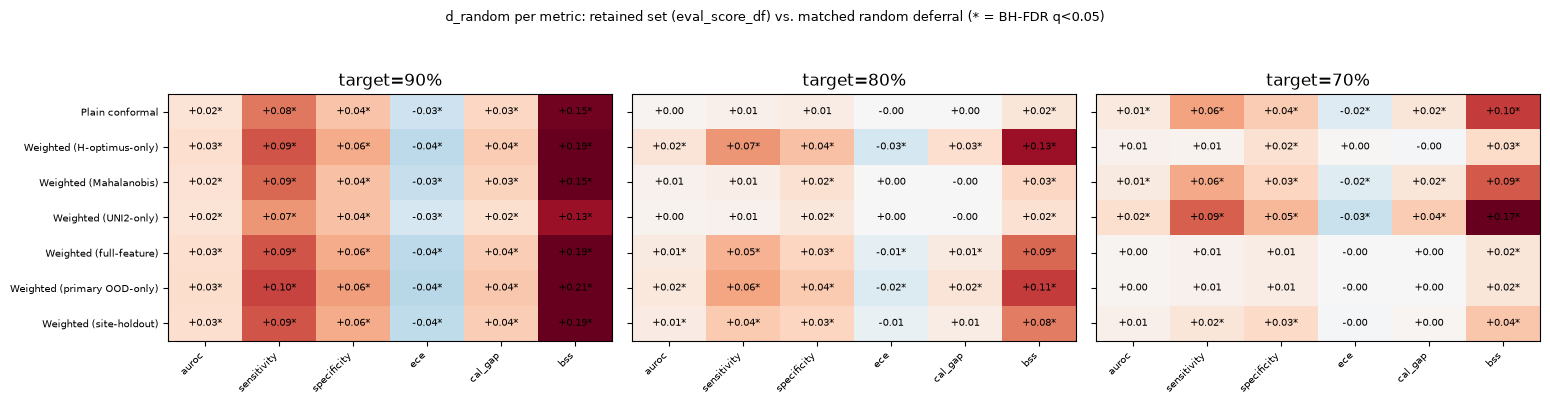

In [16]:
full_metrics = metric_suite(y_all, p_all, 0.5)
print("No-conformal full-cohort LEAD panel (baseline, n={}):".format(len(y_all)))
for m in LEAD_METRICS:
    print(f"  {m}: {full_metrics[m]:.3f}")

panel_rows = []
for cov in TARGET_COVERAGES:
    for method_key, sets in METHOD_SETS.items():
        in0, in1 = sets[cov]
        retained = (in0 + in1) == 1
        n_keep = int(retained.sum())
        if n_keep == 0:
            continue
        y_ret, p_ret = y_all[retained], p_all[retained]
        ret_metrics = metric_suite(y_ret, p_ret, 0.5)
        null = random_deferral_null(y_all, p_all, 0.5, n_keep, n_rep=N_RANDOM_DEFERRAL,
                                     seed=stable_seed("panel_null", method_key, cov))
        for metric in LEAD_METRICS:
            obs = ret_metrics[metric]
            null_vals = null[metric]
            d_full = obs - full_metrics[metric] if np.isfinite(obs) else np.nan
            d_random = obs - np.nanmean(null_vals) if np.isfinite(obs) else np.nan
            p_val = perm_p_two_sided(obs, null_vals) if np.isfinite(obs) else np.nan
            panel_rows.append({
                "target_coverage": cov, "method": method_key,
                "method_label": METHOD_LABELS[method_key],
                "metric": metric, "n_retained": n_keep,
                "full": full_metrics[metric], "retained": obs,
                "d_full": d_full, "random_mean": float(np.nanmean(null_vals)),
                "d_random": d_random, "p": p_val,
            })

panel_table = pd.DataFrame(panel_rows)
panel_table["q"] = bh_fdr(panel_table["p"].fillna(1.0).to_numpy())
panel_table["significant_q05"] = (panel_table["q"] < 0.05) & panel_table["p"].notna()
panel_table.to_csv(OUT_DIR / "metric_panel.csv", index=False)

print(f"\nMetric panel table: {len(panel_table)} rows "
      f"({len(TARGET_COVERAGES)} targets x {len(METHOD_SETS)} methods x {len(LEAD_METRICS)} metrics)")
n_sig = int(panel_table["significant_q05"].sum())
print(f"BH-FDR q<0.05 significant cells: {n_sig}/{len(panel_table)}")

def _fmt(row):
    sig = "*" if row["significant_q05"] else ""
    return f"{row['d_random']:+.3f}{sig}" if np.isfinite(row["d_random"]) else "NA"

panel_table["d_random_fmt"] = panel_table.apply(_fmt, axis=1)

for cov in TARGET_COVERAGES:
    print(f"\n=== target={cov:.0%}: retained-set LEAD panel ===")
    display(panel_table[panel_table["target_coverage"] == cov]
            .pivot(index="method_label", columns="metric", values="retained")[LEAD_METRICS].round(3))
    print(f"d_random (retained - matched-random-deferral mean), * = BH-FDR q<0.05:")
    display(panel_table[panel_table["target_coverage"] == cov]
            .pivot(index="method_label", columns="metric", values="d_random_fmt")[LEAD_METRICS])

fig, axes = plt.subplots(1, len(TARGET_COVERAGES), figsize=(5.2 * len(TARGET_COVERAGES), 3.8), sharey=True)
for ax, cov in zip(axes, TARGET_COVERAGES):
    sub = panel_table[panel_table["target_coverage"] == cov]
    mat = sub.pivot(index="method_label", columns="metric", values="d_random")[LEAD_METRICS]
    qmat = sub.pivot(index="method_label", columns="metric", values="q")[LEAD_METRICS]
    im = ax.imshow(mat.values, cmap="RdBu_r", vmin=-0.15, vmax=0.15, aspect="auto")
    for yi in range(mat.shape[0]):
        for xi in range(mat.shape[1]):
            val = mat.values[yi, xi]
            if np.isfinite(val):
                sig = "*" if qmat.values[yi, xi] < 0.05 else ""
                ax.text(xi, yi, f"{val:+.2f}{sig}", ha="center", va="center", fontsize=7)
    ax.set_xticks(range(len(LEAD_METRICS)))
    ax.set_xticklabels(LEAD_METRICS, rotation=45, ha="right", fontsize=7)
    ax.set_title(f"target={cov:.0%}")
axes[0].set_yticks(range(len(mat.index)))
axes[0].set_yticklabels(mat.index, fontsize=7)
fig.suptitle("d_random per metric: retained set (eval_score_df) vs. matched random deferral (* = BH-FDR q<0.05)",
             y=1.05, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / "metric_panel_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 11b. Retained-set quality vs. plain conformal, all schemes (direct, paired)

**Motivation.** Section 11 compares each scheme's retained set against the
full cohort and a matched-random-deferral null -- it never directly compares
one scheme's retained set to plain's. Given Section 8's correction (plain
already meets coverage), the real question is not "does weighting fix
coverage" but "what does weighting cost or buy on top of an already-valid
baseline." Paired bootstrap: resample `eval_score_df` patient indices once
per replicate, apply both methods' already-fixed prediction-set rules to the
same resampled data, compute retained-set metrics for each, and take the
difference -- the same resampling logic Section 8 already used for coverage,
extended to the full LEAD panel.

In [ ]:
def retained_metric_vs_plain(method_key, cov):
    in0_p, in1_p = METHOD_SETS["plain"][cov]
    in0_s, in1_s = METHOD_SETS[method_key][cov]
    ret_plain = (in0_p + in1_p) == 1
    ret_s = (in0_s + in1_s) == 1
    n_plain, n_s = int(ret_plain.sum()), int(ret_s.sum())
    m_plain = metric_suite(y_all[ret_plain], p_all[ret_plain], 0.5)
    m_s = metric_suite(y_all[ret_s], p_all[ret_s], 0.5)

    N = len(y_all)
    rng_b = np.random.default_rng(stable_seed("retained_vs_plain", method_key, cov))
    idx_b = rng_b.integers(0, N, size=(N_BOOT, N))
    diffs = {m: [] for m in LEAD_METRICS}
    for b in range(N_BOOT):
        bi = idx_b[b]
        yb, pb = y_all[bi], p_all[bi]
        retb_plain, retb_s = ret_plain[bi], ret_s[bi]
        mp = metric_suite(yb[retb_plain], pb[retb_plain], 0.5)
        ms = metric_suite(yb[retb_s], pb[retb_s], 0.5)
        for m in LEAD_METRICS:
            if np.isfinite(mp[m]) and np.isfinite(ms[m]):
                diffs[m].append(ms[m] - mp[m])

    rows = []
    for m in LEAD_METRICS:
        d = np.array(diffs[m])
        obs = m_s[m] - m_plain[m]
        if len(d) > 10:
            lo, hi = np.percentile(d, 2.5), np.percentile(d, 97.5)
            p_val = min(1.0, 2 * min((np.sum(d <= 0) + 1) / (len(d) + 1), (np.sum(d >= 0) + 1) / (len(d) + 1)))
        else:
            lo, hi, p_val = np.nan, np.nan, np.nan
        rows.append({"target_coverage": cov, "method": method_key, "metric": m,
                     "n_retained_plain": n_plain, "n_retained_method": n_s,
                     "plain_retained": m_plain[m], "method_retained": m_s[m],
                     "delta": obs, "ci_lo": lo, "ci_hi": hi, "p": p_val})
    return rows


retained_vs_plain_rows = []
for cov in TARGET_COVERAGES:
    for method_key in ["weighted_primary", "weighted_fullfeat", "weighted_maha",
                        "weighted_siteholdout", "weighted_uni2only", "weighted_hoptimusonly"]:
        retained_vs_plain_rows.extend(retained_metric_vs_plain(method_key, cov))

retained_vs_plain_df = pd.DataFrame(retained_vs_plain_rows)
retained_vs_plain_df["q"] = bh_fdr(retained_vs_plain_df["p"].fillna(1.0).to_numpy())
retained_vs_plain_df["sig"] = (retained_vs_plain_df["q"] < 0.05) & retained_vs_plain_df["p"].notna()
retained_vs_plain_df.to_csv(OUT_DIR / "retained_quality_vs_plain.csv", index=False)

print(f"Total cells: {len(retained_vs_plain_df)}, significant (q<0.05): {int(retained_vs_plain_df['sig'].sum())}")
for cov in TARGET_COVERAGES:
    print(f"\n########## target={cov:.0%} ##########")
    sub = retained_vs_plain_df[retained_vs_plain_df.target_coverage == cov]
    piv = sub.pivot(index="method", columns="metric", values="delta")[LEAD_METRICS]
    qpiv = sub.pivot(index="method", columns="metric", values="q")[LEAD_METRICS]
    fmt = piv.copy()
    for c in fmt.columns:
        fmt[c] = [f"{v:+.3f}{chr(42) if q < 0.05 else chr(32)}" for v, q in zip(piv[c], qpiv[c])]
    display(fmt)

Total cells: 108, significant (q<0.05): 47

########## target=90% ##########


metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method,,,,,,
weighted_fullfeat,+0.005*,+0.016,+0.012,-0.006,+0.007,+0.044*
weighted_hoptimusonly,+0.005,+0.015,+0.012,-0.005,+0.007,+0.042*
weighted_maha,+0.001,+0.007,+0.000,-0.003,+0.003,+0.009
weighted_primary,+0.006,+0.021,+0.020,-0.007,+0.009,+0.063*
weighted_siteholdout,+0.005*,+0.016,+0.012,-0.006,+0.007,+0.044*
weighted_uni2only,-0.000,-0.013,+0.000,+0.006,-0.006,-0.015



########## target=80% ##########


metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method,,,,,,
weighted_fullfeat,+0.009*,+0.045*,+0.022,-0.013,+0.013,+0.067*
weighted_hoptimusonly,+0.015*,+0.060*,+0.033*,-0.023*,+0.025*,+0.111*
weighted_maha,+0.003*,+0.003,+0.012,+0.001,-0.001,+0.013*
weighted_primary,+0.011*,+0.053*,+0.028*,-0.018,+0.019,+0.087*
weighted_siteholdout,+0.009*,+0.033*,+0.022,-0.010,+0.010,+0.059*
weighted_uni2only,+0.001,-0.001,+0.006,+0.001,-0.001,+0.004



########## target=70% ##########


metric,auroc,sensitivity,specificity,ece,cal_gap,bss
method,,,,,,
weighted_fullfeat,-0.011*,-0.054*,-0.028*,+0.017*,-0.018,-0.087*
weighted_hoptimusonly,-0.009*,-0.055*,-0.016,+0.020*,-0.021*,-0.078*
weighted_maha,-0.002*,-0.004,-0.006,+0.000,-0.000,-0.013*
weighted_primary,-0.011*,-0.054*,-0.028*,+0.017*,-0.018,-0.087*
weighted_siteholdout,-0.007*,-0.042*,-0.010,+0.015,-0.016,-0.063*
weighted_uni2only,+0.008*,+0.028,+0.011,-0.012,+0.020*,+0.064*


## 11c. Per-site coverage: does the aggregate number hide institution-level failures?

**Motivation.** Section 8 established plain conformal already meets
*aggregate* coverage at every target. Aggregate validity does not imply
per-institution validity -- a model deployed at one specific site cares
about that site's own coverage, not a patient-weighted average across 30
sites. `eval_score_df` has 30 distinct sites (n=337 total), most very
small (median 4.5 patients/site, half have <=2) -- those give essentially
a coin-flip coverage estimate and are reported for completeness but not
leaned on. Sites with n>=15 (6 sites) give a real answer.

In [ ]:
def per_site_coverage(method_key, cov):
    in0, in1 = METHOD_SETS[method_key][cov]
    covered = np.where(y_score_11c == 1, in1, in0).astype(bool)
    out = pd.DataFrame({"site": site_col_11c, "covered": covered})
    return out.groupby("site").agg(n=("covered", "size"), coverage=("covered", "mean"))


y_score_11c = eval_score_df["label"].to_numpy()
site_col_11c = eval_score_df["site"].to_numpy()
print(f"eval_score_df: {eval_score_df['site'].nunique()} distinct sites, n={len(eval_score_df)}")
print(eval_score_df["site"].value_counts().describe().round(2))

site_summary_rows = []
for cov in TARGET_COVERAGES:
    g_plain = per_site_coverage("plain", cov)
    n_sites = len(g_plain)
    for method_key in ["plain", "weighted_primary", "weighted_hoptimusonly"]:
        g = per_site_coverage(method_key, cov)
        for min_n, label in [(1, "all_sites"), (5, "n_gte_5"), (15, "n_gte_15")]:
            sub = g[g["n"] >= min_n]
            site_summary_rows.append({
                "target_coverage": cov, "method": method_key, "site_filter": label,
                "n_sites": len(sub), "n_above_target": int((sub["coverage"] >= cov).sum()),
                "frac_above_target": float((sub["coverage"] >= cov).mean()) if len(sub) else np.nan,
                "mean_site_coverage": float(sub["coverage"].mean()) if len(sub) else np.nan,
            })

site_summary = pd.DataFrame(site_summary_rows)
site_summary.to_csv(OUT_DIR / "per_site_coverage_summary.csv", index=False)
display(site_summary[site_summary.site_filter != "all_sites"].round(3))

print("\nBig sites (n>=15) at 80% target, plain vs. primary vs. H-optimus-only:")
g_plain80 = per_site_coverage("plain", 0.80)
g_pr80 = per_site_coverage("weighted_primary", 0.80)
g_h80 = per_site_coverage("weighted_hoptimusonly", 0.80)
big_sites = g_plain80[g_plain80["n"] >= 15].index.tolist()
big_comp = pd.DataFrame({
    "n": g_plain80.loc[big_sites, "n"],
    "plain": g_plain80.loc[big_sites, "coverage"],
    "primary": g_pr80.loc[big_sites, "coverage"],
    "hoptimus_only": g_h80.loc[big_sites, "coverage"],
}).sort_values("n", ascending=False)
big_comp.to_csv(OUT_DIR / "big_site_coverage_80pct.csv")
display(big_comp.round(3))

eval_score_df: 30 distinct sites, n=337
count    30.00
mean     11.23
std      18.27
min       1.00
25%       1.25
50%       4.50
75%      12.25
max      89.00
Name: count, dtype: float64


,target_coverage,method,site_filter,n_sites,n_above_target,frac_above_target,mean_site_coverage
1,0.9,plain,n_gte_5,15,14,0.933,0.964
2,0.9,plain,n_gte_15,6,5,0.833,0.952
4,0.9,weighted_primary,n_gte_5,15,15,1.000,0.986
5,0.9,weighted_primary,n_gte_15,6,6,1.000,0.965
7,0.9,weighted_hoptimusonly,n_gte_5,15,15,1.000,0.976
8,0.9,weighted_hoptimusonly,n_gte_15,6,6,1.000,0.957
10,0.8,plain,n_gte_5,15,13,0.867,0.915
11,0.8,plain,n_gte_15,6,4,0.667,0.867
13,0.8,weighted_primary,n_gte_5,15,15,1.000,0.958
14,0.8,weighted_primary,n_gte_15,6,6,1.000,0.938



Big sites (n>=15) at 80% target, plain vs. primary vs. H-optimus-only:


,n,plain,primary,hoptimus_only
site,,,,
Henry Ford Hospital,89,0.787,0.910,0.933
Case Western - St Joes,52,0.788,0.885,0.885
Duke,27,0.815,0.926,0.963
MD Anderson Cancer Center,22,0.909,0.909,0.909
Dept of Neurosurgery at University of Heidelberg,21,0.905,1.000,1.000
Mayo Clinic - Rochester,18,1.000,1.000,1.000


## 12. Robustness check: does the single weight/score split matter?

**Motivation.** Section 2 used one fixed, deterministic 50/50 split of
`eval_df`. This checks whether that specific split happened to be
favourable by re-running the primary scheme's coverage comparison across
20 independent random weight/score partitions.

In [ ]:
N_SPLITS = 20
robustness_rows = []
for split_seed in range(N_SPLITS):
    rng_s = np.random.default_rng(split_seed)
    idx_s = rng_s.permutation(len(eval_df))
    half_s = len(idx_s) // 2
    ewd = eval_df.iloc[idx_s[:half_s]].reset_index(drop=True)
    esd = eval_df.iloc[idx_s[half_s:]].reset_index(drop=True)
    plain_w_cal = np.ones(len(cal_df))
    for cov, alpha in zip(TARGET_COVERAGES, ALPHAS):
        q_hat_plain = conformal_quantile(cal_scores_true, alpha)
        in0p, in1p = prediction_sets(esd["prob_mutant"].to_numpy(), q_hat_plain)
        covered_plain = np.where(esd["label"].to_numpy() == 1, in1p, in0p).astype(bool)

        cal_w, score_w, auroc = build_weights_leakfree(cal_df, ewd, esd, OOD_ONLY_FEATURES)
        in0, in1 = sets_for(esd, cal_scores_true, cal_w, score_w, alpha)
        covered_w = np.where(esd["label"].to_numpy() == 1, in1, in0).astype(bool)

        robustness_rows.append({"split_seed": split_seed, "target_coverage": cov,
                                 "plain_coverage": covered_plain.mean(), "weighted_coverage": covered_w.mean(),
                                 "delta": covered_w.mean() - covered_plain.mean(), "domain_auroc": auroc})

robustness_df = pd.DataFrame(robustness_rows)
robustness_summary = robustness_df.groupby("target_coverage").agg(
    plain_coverage=("plain_coverage", "mean"), weighted_coverage_mean=("weighted_coverage", "mean"),
    weighted_coverage_std=("weighted_coverage", "std"), delta_mean=("delta", "mean"), delta_std=("delta", "std"),
    domain_auroc_mean=("domain_auroc", "mean"),
).reset_index().sort_values("target_coverage", ascending=False)
robustness_summary.to_csv(OUT_DIR / "split_robustness_check.csv", index=False)
print(f"Averaged over {N_SPLITS} independent random weight/score splits:")
display(robustness_summary.round(4))

Averaged over 20 independent random weight/score splits:


,target_coverage,plain_coverage,weighted_coverage_mean,weighted_coverage_std,delta_mean,delta_std,domain_auroc_mean
2,0.9,0.9628,0.9783,0.0057,0.0156,0.0059,0.6124
1,0.8,0.8592,0.9528,0.0134,0.0936,0.0170,0.6124
0,0.7,0.7972,0.8890,0.0257,0.0918,0.0253,0.6124


## 13. Limitations

- **Single deterministic weight/score split for the main results (Section
  8)**, matching the convention used for `NEW_CALIBRATION_SITES` itself.
  Section 12 checks robustness across 20 random splits, not a
  pre-registered set of alternatives.
- **The 50/50 split halves the effective evaluation sample** (n=337
  instead of n=674) relative to the original in-sample notebook. Some
  loss of precision (wider CIs, and a real drop from 89/90 to 66/90
  significant metric-panel cells in Section 11) is the direct cost of
  testing generalisation properly rather than in-sample fit.
- **Per-site coverage (Section 11c) is now included**, but most of
  `eval_score_df`'s 30 sites have too few patients (median 4.5, half <=2)
  for an individual site's coverage number to be more than a coin flip --
  only the n>=15 sites (6 of them) support the conclusion drawn from
  them; the rest are reported for transparency, not leaned on.
- **Sections 9-11c (baseline, selective breakdown, metric panel,
  retained-quality-vs-plain, per-site coverage) are now all included** --
  every check from the original notebook is replicated here, plus three
  new ones motivated by what checking properly revealed: the
  encoder-isolation ablation (7b), the direct retained-quality-vs-plain
  comparison (11b), and per-site coverage (11c).

## Saved artifacts

In [18]:
for f in sorted(OUT_DIR.glob("*")):
    print(f)

/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/big_site_coverage_80pct.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/coverage_comparison.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/metric_panel.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/metric_panel_heatmap.png
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/no_conformal_baseline.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/per_site_coverage_summary.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/retained_quality_vs_plain.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_free/selective_breakdown.csv
/cs/student/project_msc/2025/aibh/mpapageo/outputs/shift_weighted_conformal_leakage_